### SDP + PhytoClass: eddy-wide transformation summary

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRACK_ID = 13
DATE = pd.Timestamp("2025-03-29")

# Diagnostic biomarker pigments (T chla shown separately as annotation since it dominates the scale)
PIGMENT_NAMES = ["DV chla", "MV chlb", "chl c1+c2", "chl c3",
                 "Fuco", "ButFuco", "HexFuco", "Perid", "Allo", "Zea", "Viola", "Neo"]

# Presentable display names for the x-axis
PIGMENT_DISPLAY = [
    "DV Chl-a", "MV Chl-b", "Chl-c1+c2", "Chl-c3",
    "Fucoxanthin", "But-Fuco", "Hex-Fuco", "Peridinin",
    "Alloxanthin", "Zeaxanthin", "Violaxanthin", "Neoxanthin",
]

PFT_NAMES = ["Diatoms", "Dinoflagellates", "Haptophytes",
             "Cryptophytes", "Green_algae", "Cyanobacteria"]

PFT_COLORS = {
    "Diatoms":         "#E87A14",
    "Dinoflagellates": "#C62828",
    "Haptophytes":     "#FFB347",
    "Cryptophytes":    "#AD1457",
    "Green_algae":     "#2E7D32",
    "Cyanobacteria":   "#1565C0",
}

# Each biomarker pigment is colored by its primary PFT association
PIGMENT_COLORS = [
    "#1565C0",  # DV chla -> Cyanobacteria (Prochlorococcus)
    "#2E7D32",  # MV chlb -> Green algae
    "#FFB347",  # chl c1+c2 -> Haptophytes
    "#FFB347",  # chl c3 -> Haptophytes
    "#E87A14",  # Fuco -> Diatoms
    "#FFB347",  # ButFuco -> Haptophytes
    "#FFB347",  # HexFuco -> Haptophytes
    "#C62828",  # Perid -> Dinoflagellates
    "#AD1457",  # Allo -> Cryptophytes
    "#1565C0",  # Zea -> Cyanobacteria
    "#2E7D32",  # Viola -> Green algae
    "#2E7D32",  # Neo -> Green algae
]

In [2]:
# Load pigments and PFTs, filter to the target date
pig = pd.read_parquet(ROOT / f"outputs/gulf_stream_20241001_20250701/pigments/cyclone/eddy_{TRACK_ID}_pigments.parquet")
pft = pd.read_parquet(ROOT / f"outputs/gulf_stream_20241001_20250701/pft/cyclone/eddy_{TRACK_ID}_pfts.parquet")

pig_d = pig[pig["date"] == DATE].reset_index(drop=True)
pft_d = pft[pft["date"] == DATE].reset_index(drop=True)
n_pixels = len(pig_d)

# Eddy-wide pigment mean and std (raw concentrations)
pig_mean = pig_d[PIGMENT_NAMES].mean().values
pig_std = pig_d[PIGMENT_NAMES].std().values
total_chla_mean = pig_d["T chla"].mean()

# PhytoClass outputs chl-a concentration per PFT (mg/m^3).
# Express each pixel's PFT values as a fraction of that pixel's total chl-a,
# then take the eddy-wide mean/std.
t_chla = pig_d["T chla"].values
pft_vals = pft_d[PFT_NAMES].values
pft_frac = pft_vals / t_chla[:, None]
pft_mean = pft_frac.mean(axis=0)
pft_std = pft_frac.std(axis=0)

print(f"n pixels: {n_pixels}")
print(f"Mean Total Chl-a: {total_chla_mean:.3f} mg m^-3")
print(f"Dominant PFT (mean fraction of T chl-a): {PFT_NAMES[np.argmax(pft_mean)]} ({pft_mean.max():.2f})")

n pixels: 1644
Mean Total Chl-a: 0.611 mg m^-3
Dominant PFT (mean fraction of T chl-a): Diatoms (0.39)


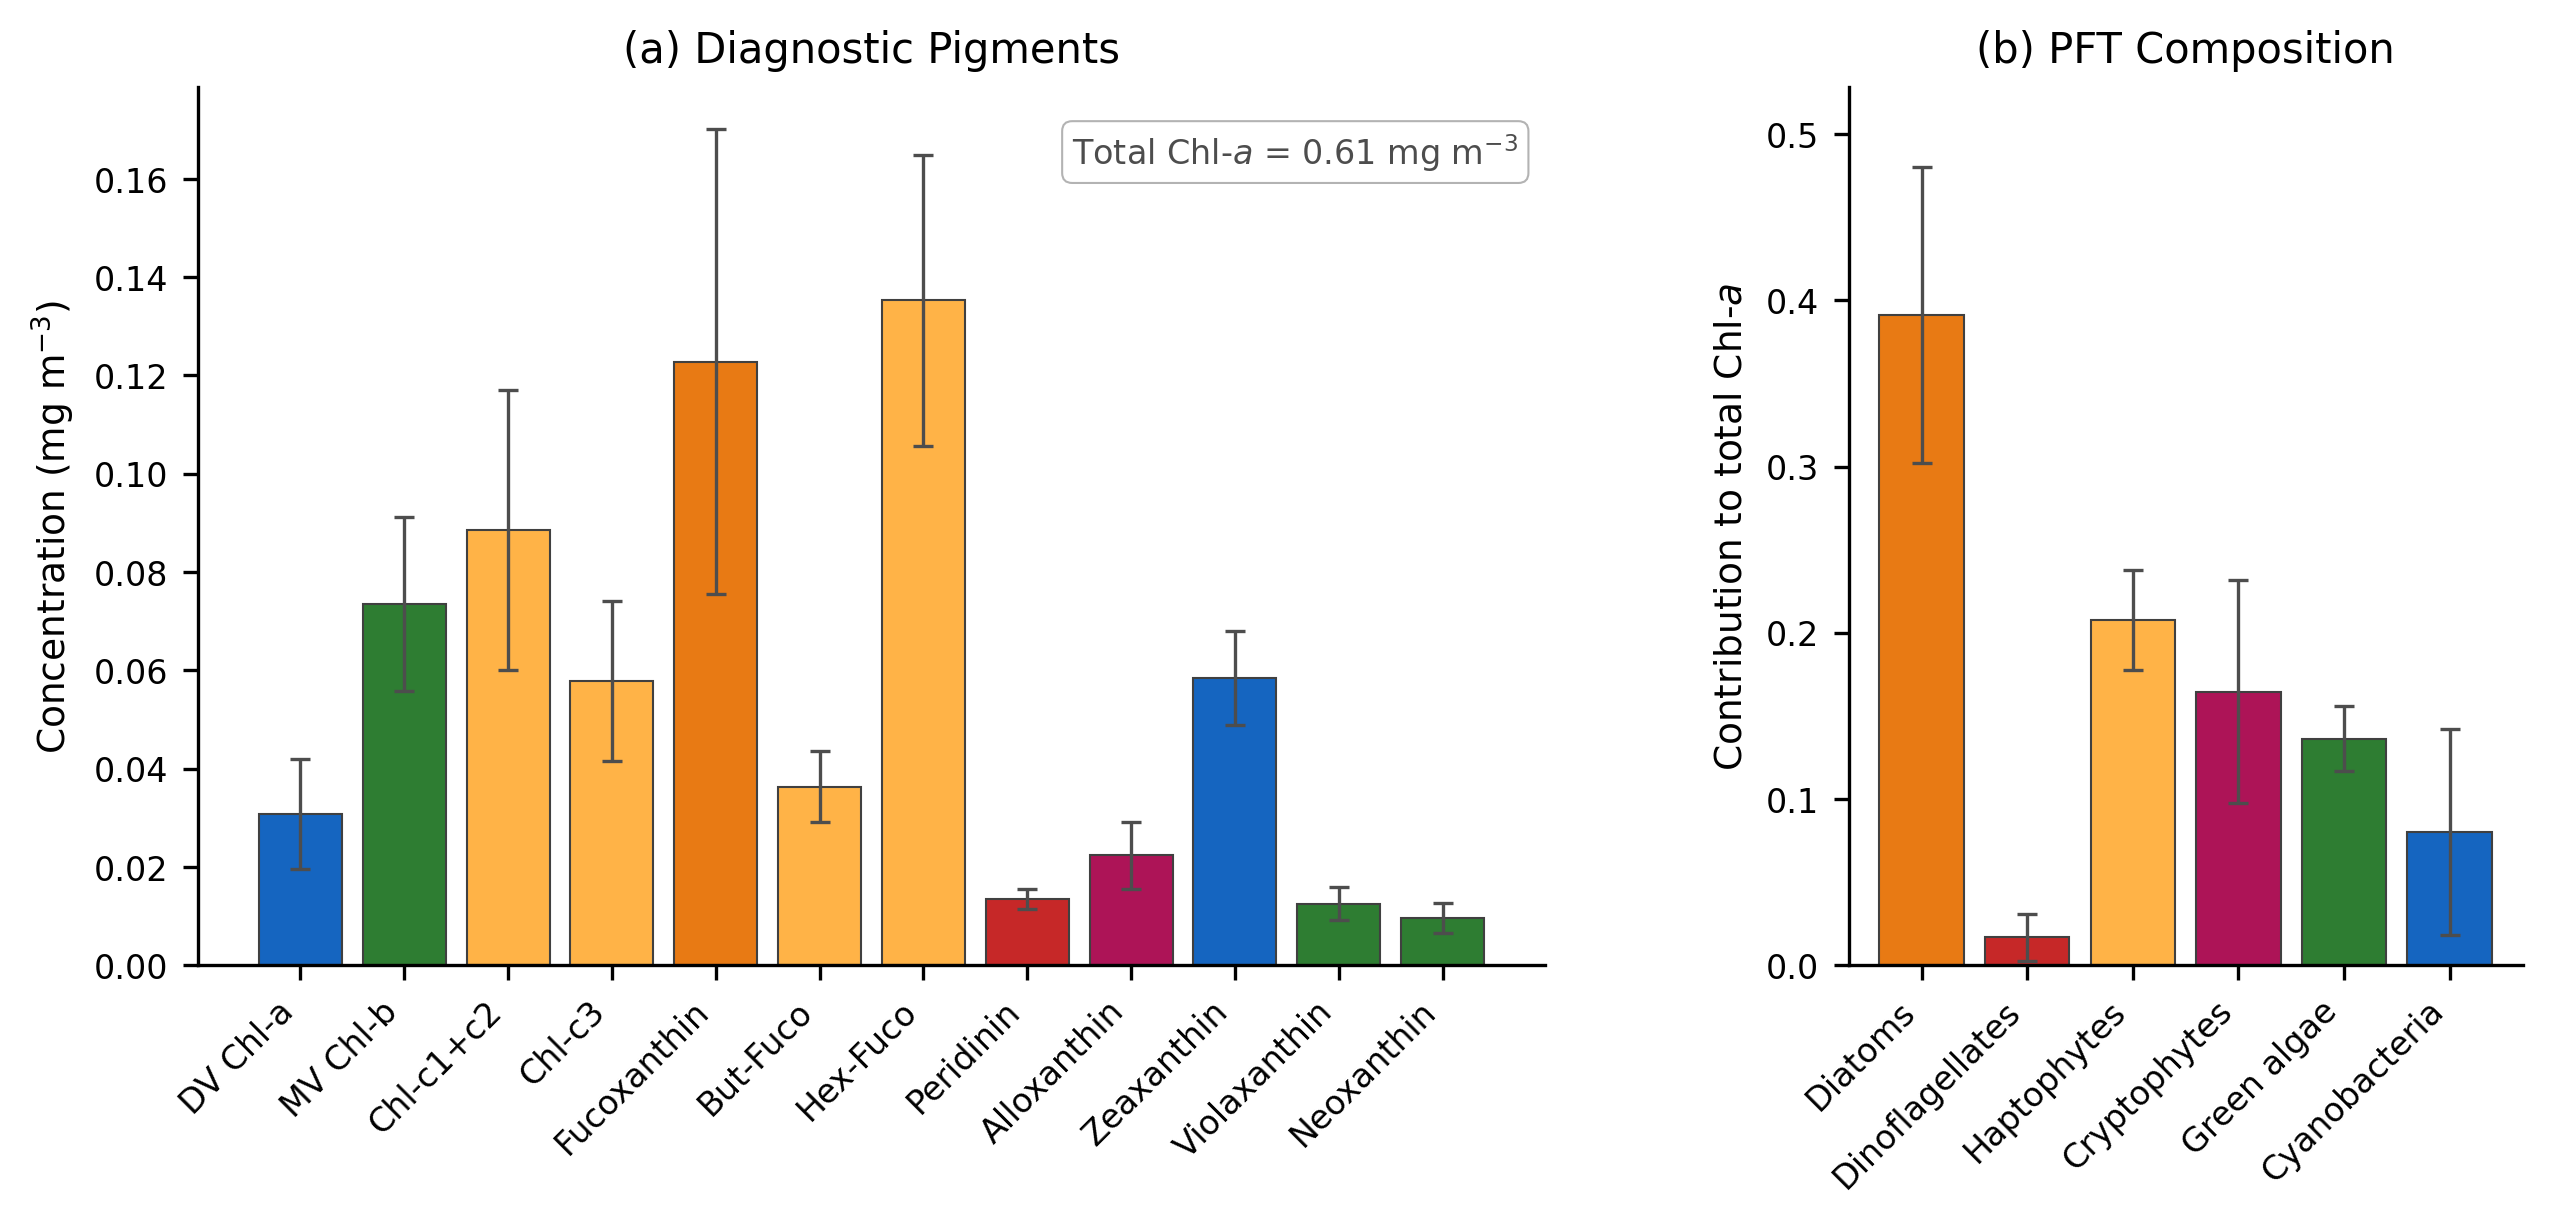

In [3]:
pft_bar_colors = [PFT_COLORS[p] for p in PFT_NAMES]

fig = plt.figure(figsize=(10, 3.8), dpi=300)
gs = fig.add_gridspec(1, 2, wspace=0.30, width_ratios=[2.0, 1.0])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# Panel A: Diagnostic pigment concentrations (mean +/- std across eddy)
x_pos = np.arange(len(PIGMENT_NAMES))
ax1.bar(x_pos, pig_mean, yerr=pig_std, color=PIGMENT_COLORS,
        edgecolor="0.25", linewidth=0.5,
        error_kw=dict(ecolor="0.3", lw=0.8, capsize=2.5, capthick=0.8))
ax1.set_xticks(x_pos)
ax1.set_xticklabels(PIGMENT_DISPLAY, rotation=45, ha="right", fontsize=8)
ax1.set_ylabel(r"Concentration (mg m$^{-3}$)", fontsize=9)
ax1.tick_params(labelsize=8)
ax1.spines[["top", "right"]].set_visible(False)
ax1.set_title("(a) Diagnostic Pigments", fontsize=10, pad=6)
ax1.text(0.98, 0.95, f"Total Chl-$a$ = {total_chla_mean:.2f} mg m$^{{-3}}$",
         transform=ax1.transAxes, fontsize=8, ha="right", va="top", color="0.3",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.7", linewidth=0.5))

# Panel B: PFT contributions to total Chl-a (mean +/- std across eddy)
x_pos2 = np.arange(len(PFT_NAMES))
pft_labels = [p.replace("_", " ") for p in PFT_NAMES]
ax2.bar(x_pos2, pft_mean, yerr=pft_std, color=pft_bar_colors,
        edgecolor="0.25", linewidth=0.5,
        error_kw=dict(ecolor="0.3", lw=0.8, capsize=2.5, capthick=0.8))
ax2.set_xticks(x_pos2)
ax2.set_xticklabels(pft_labels, rotation=45, ha="right", fontsize=8)
ax2.set_ylabel(r"Contribution to total Chl-$a$", fontsize=9)
ax2.set_ylim(0, (pft_mean + pft_std).max() * 1.10)
ax2.tick_params(labelsize=8)
ax2.spines[["top", "right"]].set_visible(False)
ax2.set_title("(b) PFT Composition", fontsize=10, pad=6)

fig.savefig("sdp_phytoclass.png", dpi=300, bbox_inches="tight")
plt.show()